In [1]:
import matplotlib.pyplot as plt
import numpy as np
import scipy.sparse as sp

from qiskit import QuantumCircuit, QuantumRegister, transpile
from qiskit.circuit.library import XGate, RYGate
from qiskit.quantum_info import partial_trace
from qiskit_aer import AerSimulator
from shift_operators import ShiftDown, ShiftUp

In [2]:
data = QuantumRegister(1, "data")
l = QuantumRegister(2, "l")
j0 = QuantumRegister(3, "j0")
j1 = QuantumRegister(3, "j1")
k = QuantumRegister(1, "k")
simulator = AerSimulator(method="unitary")

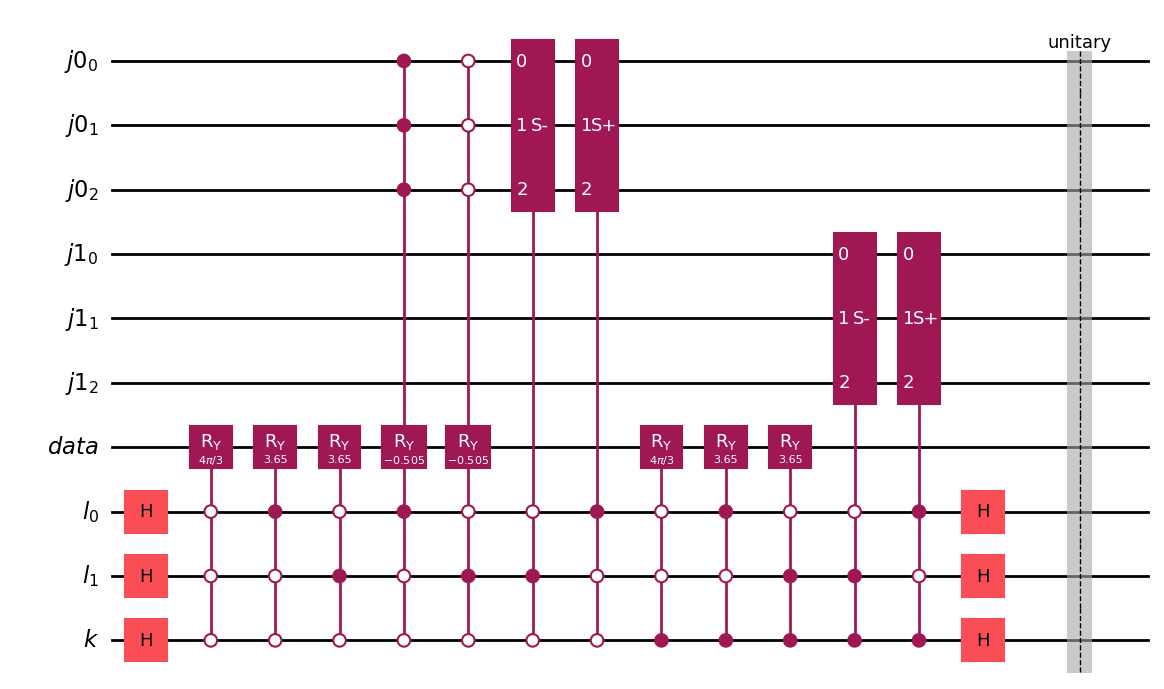

In [69]:
qc = QuantumCircuit(j0, j1, data, l, k)
diag_theta = 2 * np.arccos(0.5 - 1)
off_theta = 2 * np.arccos(-0.25)

csdown = ShiftDown(3).control(3, ctrl_state="100")
csup = ShiftUp(3).control(3, ctrl_state="010")
cry0 = RYGate(diag_theta).control(3, ctrl_state="000")
cry1 = RYGate(off_theta).control(3, ctrl_state="010")
cry2 = RYGate(off_theta).control(3, ctrl_state="100")

dirichlet_correction0 = RYGate(np.pi - off_theta).control(6, ctrl_state="111010")
dirichlet_correction1 = RYGate(np.pi - off_theta).control(6, ctrl_state="000100")


qc.h(l)
qc.h(k)
qc.append(cry0, k[:] + l[:] + data[:])
qc.append(cry1, k[:] + l[:] + data[:])
qc.append(cry2, k[:] + l[:] + data[:])
qc.append(dirichlet_correction0, k[:] + l[:] + j0[:] + data[:])
qc.append(dirichlet_correction1, k[:] + l[:] + j0[:] + data[:])
qc.append(csdown, k[:] + l[:] + j0[:])
qc.append(csup, k[:] + l[:] + j0[:])

csdown = ShiftDown(3).control(3, ctrl_state="101")
csup = ShiftUp(3).control(3, ctrl_state="011")
cry0 = RYGate(diag_theta).control(3, ctrl_state="001")
cry1 = RYGate(off_theta).control(3, ctrl_state="011")
cry2 = RYGate(off_theta).control(3, ctrl_state="101")

dirichlet_correction0 = RYGate(np.pi - off_theta).control(6, ctrl_state="111011")
dirichlet_correction1 = RYGate(np.pi - off_theta).control(6, ctrl_state="000101")

qc.append(cry0, k[:] + l[:] + data[:])
qc.append(cry1, k[:] + l[:] + data[:])
qc.append(cry2, k[:] + l[:] + data[:])
# qc.append(dirichlet_correction0, k[:] + l[:] + j1[:] + data[:])
# qc.append(dirichlet_correction1, k[:] + l[:] + j1[:] + data[:])
qc.append(csdown, k[:] + l[:] + j1[:])
qc.append(csup, k[:] + l[:] + j1[:])
# qc.cy(l[0], data[0])

qc.h(l)
qc.h(k)

qc.save_unitary()
qc.draw(output="mpl")

In [70]:
qc = transpile(qc, simulator)

result = simulator.run(qc).result()
unitary = result.get_unitary(qc).data
unitary = (unitary / unitary[0, 0] * -0.5).real

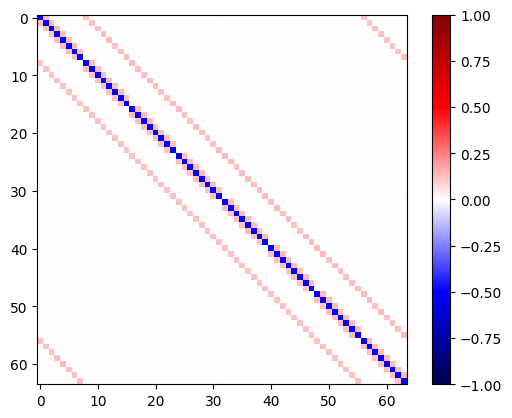

In [71]:
plt.imshow(unitary[:64, :64], vmin=-1, vmax=1, cmap="seismic")
plt.colorbar()

In [68]:
print(np.round(unitary[:8, :8], 3).real)

[[-0.5    0.125 -0.    -0.     0.    -0.    -0.    -0.   ]
 [ 0.125 -0.5    0.125 -0.     0.    -0.     0.    -0.   ]
 [ 0.     0.125 -0.5    0.125  0.     0.     0.    -0.   ]
 [-0.     0.     0.125 -0.5    0.125  0.     0.     0.   ]
 [-0.    -0.    -0.     0.125 -0.5    0.125 -0.     0.   ]
 [ 0.    -0.    -0.    -0.     0.125 -0.5    0.125 -0.   ]
 [ 0.     0.    -0.    -0.     0.     0.125 -0.5    0.125]
 [-0.     0.     0.    -0.     0.     0.     0.125 -0.5  ]]
